In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [3]:
ctype = np.float64

### `init_grid`
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells
output: `grid` 2darray of boolean
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [4]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [5]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh


### `life_step(grid)` :
- input: `grid` a 2darray of cells (boolean);
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [6]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [7]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [8]:
grid = init_grid((10,10), 0.5)

In [9]:
grid

array([[0., 0., 1., 1., 1., 0., 1., 0., 0., 1.],
       [0., 1., 0., 1., 1., 1., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 0.],
       [1., 0., 1., 1., 1., 1., 0., 1., 1., 0.],
       [0., 0., 0., 0., 1., 1., 0., 0., 1., 1.],
       [1., 0., 0., 0., 1., 0., 1., 1., 1., 0.],
       [0., 1., 0., 0., 0., 0., 1., 1., 1., 0.],
       [1., 1., 0., 0., 0., 1., 1., 1., 0., 1.],
       [1., 0., 1., 0., 0., 1., 0., 1., 0., 0.],
       [1., 1., 0., 1., 1., 0., 0., 0., 1., 1.]])

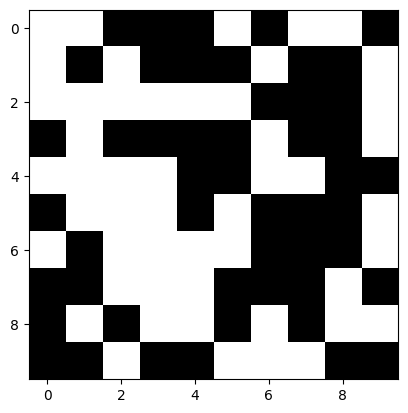

In [10]:
plt.imshow(grid,cmap=plt.cm.binary)

In [11]:
grid0 = grid

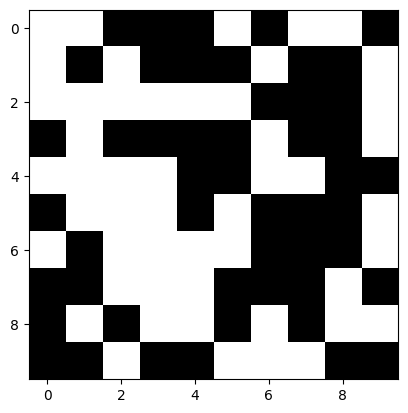

In [12]:
plt.imshow(grid,cmap=plt.cm.binary)

In [13]:
conway(grid0,5)

alive cells: 50: 50.00%
alive cells: 27: 27.00%
alive cells: 18: 18.00%
alive cells: 17: 17.00%
alive cells: 16: 16.00%


array([[0., 0., 0., 0., 0., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 1., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 1., 0., 1., 0.]])

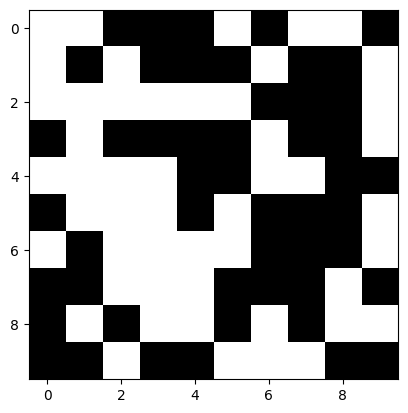

In [14]:
plt.imshow(grid0,cmap=plt.cm.binary)

## `life_step_in`

In [15]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = 0.
            # loop over neighs to count living cells
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    nb_neigh = nb_neigh + grid[ii, jj]
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh - grid[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [16]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

In [17]:
grid_100 = init_grid((10,10), 0.5)
grid_10K = init_grid((100,100), 0.5)
grid_1M  = init_grid((1000,1000), 0.5)
grid_4M  = init_grid((2000,2000), 0.5)

In [18]:
# %time life_step_in(grid_100)
# %time life_step_in(grid_10K)
# %time life_step_in(grid_1M)
# %time life_step_in(grid_4M)

## Question 1.a
Créer une fonction ```enlarge_grid(grid)``` qui, en fonction d’une grille ```grid```, retourne une grille élargie d’une colonne et d’une ligne de part et d’autre de la grille ```grid```.

In [19]:
def enlarge_grid(grid):
    return np.pad(grid, 1)

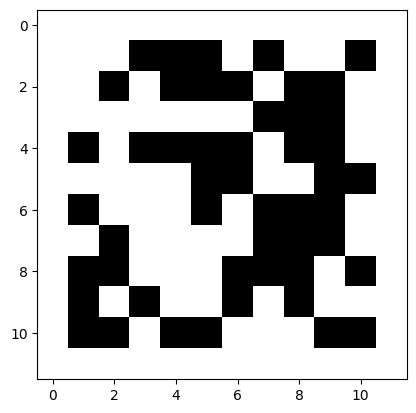

In [20]:
grid_e = enlarge_grid(grid)
plt.imshow(grid_e,cmap=plt.cm.binary)

## Question 1.b
À partir de ```life_step_in``` créer une fonction ```life_step_eg``` qui applique les règle du jeu de la vie sur une grille élargie. Attention on ne doit pas modifier les valeurs des cellules artificiellement ajoutée au bord. Modifiez ```conway``` pour utiliser cette nouvelle version.

In [21]:
def life_step_eg(grid):
    griden = enlarge_grid(grid)
    irange, jrange = griden.shape
    res_grid = np.zeros(griden.shape,dtype=ctype)
    for j in range(1, jrange-1):
        for i in range(1, irange-1):
            # by default cell_state is dead
            cell_state = 0.
            # loop over neighs to count living cells
            biinf = i - 1 #max(0, i - 1)
            bisup = i + 1 #min(irange - 1, i + 1)
            bjinf = j - 1 #max(0,j - 1)
            bjsup = j + 1 #min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    nb_neigh = nb_neigh + griden[ii, jj]
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh - griden[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = griden[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    res = np.delete(res_grid, irange-1, 0)
    res = np.delete(res, jrange-1, 1)
    res = np.delete(res, 0, 0)
    res = np.delete(res, 0, 1)
    return res

In [22]:
def conway_eg(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_eg(grid)
    return grid

In [23]:
grid = init_grid((100,100), 0.5)
res_in = conway_in(grid,2)
res_eg = conway_eg(grid,2)
print(np.array_equal(res_eg, res_in))

alive cells: 4963: 49.63%
alive cells: 2855: 28.55%
alive cells: 4963: 49.63%
alive cells: 2855: 28.55%
True


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Both functions present the same result, therefore, it applies the game of life correctly.
  </p>
</div>

## Question 1.c
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [24]:
values_n = [10, 50, 100, 250, 500, 750, 1000, 1250, 1500]
timesin = []
timeseg = []

for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")
    tic = time.time()
    %time conway_in(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    timesin.append(elapsed_time)

    tic = time.time()
    %time conway_eg(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    timeseg.append(elapsed_time)

----- n =  10  -----
alive cells: 59: 59.00%
alive cells: 34: 34.00%
alive cells: 26: 26.00%
alive cells: 25: 25.00%
alive cells: 21: 21.00%
CPU times: user 2.84 ms, sys: 0 ns, total: 2.84 ms
Wall time: 2.85 ms
alive cells: 59: 59.00%
alive cells: 34: 34.00%
alive cells: 26: 26.00%
alive cells: 25: 25.00%
alive cells: 21: 21.00%
CPU times: user 2.56 ms, sys: 0 ns, total: 2.56 ms
Wall time: 2.49 ms
----- n =  50  -----
alive cells: 1276: 51.04%
alive cells: 646: 25.84%
alive cells: 604: 24.16%
alive cells: 570: 22.80%
alive cells: 521: 20.84%
CPU times: user 48 ms, sys: 175 µs, total: 48.2 ms
Wall time: 48.4 ms
alive cells: 1276: 51.04%
alive cells: 646: 25.84%
alive cells: 604: 24.16%
alive cells: 570: 22.80%
alive cells: 521: 20.84%
CPU times: user 42.9 ms, sys: 896 µs, total: 43.8 ms
Wall time: 43.6 ms
----- n =  100  -----
alive cells: 4957: 49.57%
alive cells: 2845: 28.45%
alive cells: 2730: 27.30%
alive cells: 2642: 26.42%
alive cells: 2407: 24.07%
CPU times: user 191 ms, sys: 1.1

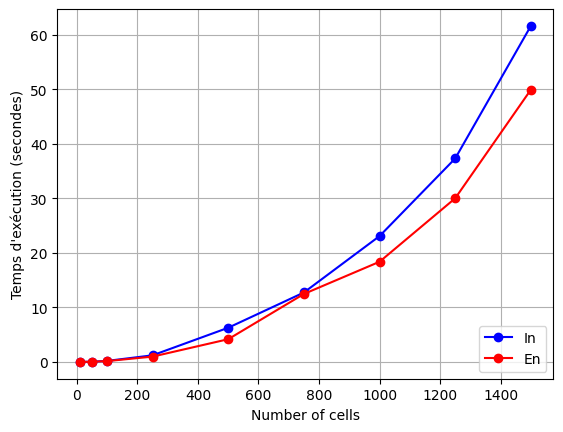

In [25]:
plt.plot(values_n, timesin, marker='o', color='blue')
plt.plot(values_n, timeseg, marker='o', color='red')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.legend(["In", "En"], loc="lower right")
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    This new function adds padding to the grid to enable more efficient navigation through neighbors, without the need for the max and min functions. As discussed in the previous TP after using the Profiler, the min and max functions were the functions with the highest number of calls during code execution. Therefore, this new function becomes more efficient and faster, as demonstrated by comparing the execution times of the two functions.
  </p>
</div>

## Question 2.a
sur la base de ```life_step_eg``` une fonction ```life_step_unroll``` qui calcule explicitement nbneigh sans la double boucle interne.

In [26]:
def life_step_ur(grid):
    griden = enlarge_grid(grid)
    irange, jrange = griden.shape
    res_grid = np.zeros(griden.shape,dtype=ctype)
    for j in range(1, jrange-1):
        for i in range(1, irange-1):
            # by default cell_state is dead
            cell_state = 0.

            nb_neigh = (
                griden[i-1, j-1] + griden[i-1, j] + griden[i-1, j+1] +
                griden[i,   j-1]                  + griden[i,   j+1] +
                griden[i+1, j-1] + griden[i+1, j] + griden[i+1, j+1]
            )

            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = griden[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    res = np.delete(res_grid, irange-1, 0)
    res = np.delete(res, jrange-1, 1)
    res = np.delete(res, 0, 0)
    res = np.delete(res, 0, 1)
    return res

In [27]:
def conway_ur(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_ur(grid)
    return grid

In [28]:
grid = init_grid((100,100), 0.5)
res_ur = conway_ur(grid,2)
res_eg = conway_eg(grid,2)
print(np.array_equal(res_eg, res_ur))

alive cells: 4956: 49.56%
alive cells: 2877: 28.77%
alive cells: 4956: 49.56%
alive cells: 2877: 28.77%
True


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Both functions present the same result, therefore, it applies the game of life correctly.
  </p>
</div>

## Question 2.b
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [29]:
timesur = []

for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")
    tic = time.time()
    %time conway_ur(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    timesur.append(elapsed_time)

----- n =  10  -----
alive cells: 52: 52.00%
alive cells: 42: 42.00%
alive cells: 25: 25.00%
alive cells: 21: 21.00%
alive cells: 16: 16.00%
CPU times: user 1.9 ms, sys: 996 µs, total: 2.9 ms
Wall time: 3.02 ms
----- n =  50  -----
alive cells: 1227: 49.08%
alive cells: 728: 29.12%
alive cells: 678: 27.12%
alive cells: 656: 26.24%
alive cells: 621: 24.84%
CPU times: user 29.7 ms, sys: 0 ns, total: 29.7 ms
Wall time: 29.8 ms
----- n =  100  -----
alive cells: 5019: 50.19%
alive cells: 2768: 27.68%
alive cells: 2513: 25.13%
alive cells: 2478: 24.78%
alive cells: 2314: 23.14%
CPU times: user 117 ms, sys: 0 ns, total: 117 ms
Wall time: 118 ms
----- n =  250  -----
alive cells: 31087: 49.74%
alive cells: 17301: 27.68%
alive cells: 16259: 26.01%
alive cells: 15735: 25.18%
alive cells: 15108: 24.17%
CPU times: user 669 ms, sys: 4.98 ms, total: 674 ms
Wall time: 676 ms
----- n =  500  -----
alive cells: 124927: 49.97%
alive cells: 68722: 27.49%
alive cells: 63704: 25.48%
alive cells: 62447: 24

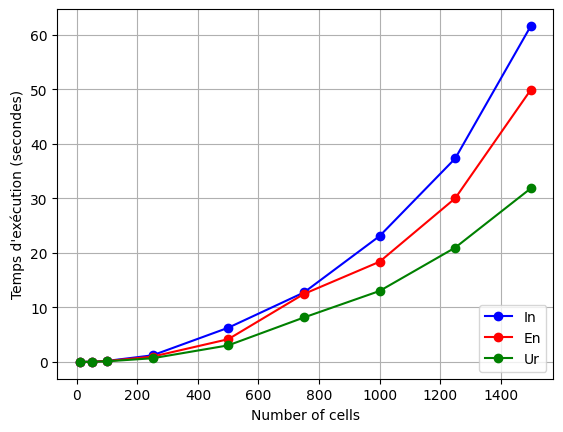

In [30]:
plt.plot(values_n, timesin, marker='o', color='blue')
plt.plot(values_n, timeseg, marker='o', color='red')
plt.plot(values_n, timesur, marker='o', color='green')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.legend(["In", "En", "Ur"], loc="lower right")
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The calculation without using the double loop contributed even more to the efficiency of the function, as it reduces the number of iterations performed by the function and directly calculates the number of live neighbors, in just one operation.
  </p>
</div>

## Question 3.a
Sur la base de ```life_step_unroll``` écrire une fonction ```life_step_store``` qui réutilise les sommes partielles déjà calculées.

In [37]:
def life_step_st(grid):
    griden = enlarge_grid(grid)
    irange, jrange = griden.shape
    res_grid = np.zeros_like(griden, dtype=float)

    # On va précalculer les sommes verticales pour les trois colonnes
    # autour de la colonne courante j : col_sum[j-1], col_sum[j], col_sum[j+1]
    # col_sum[k] = somme des trois cellules (au-dessus, celle du milieu, en-dessous)

    # initialisation pour les colonnes 0,1,2
    col_sum_prev = griden[:-2, 0] + griden[1:-1, 0] + griden[2:, 0]
    col_sum_curr = griden[:-2, 1] + griden[1:-1, 1] + griden[2:, 1]
    col_sum_next = griden[:-2, 2] + griden[1:-1, 2] + griden[2:, 2]

    # boucle sur les colonnes internes
    for j in range(1, jrange - 1):
        for i in range(1, irange - 1):
            nb_neigh = (
                col_sum_prev[i-1] +  # colonne précédente
                col_sum_curr[i-1] +  # colonne courante
                col_sum_next[i-1] - griden[i, j]  # on retire la cellule elle-même
            )

            # règles du jeu de la vie
            if nb_neigh == 2:
                res_grid[i, j] = griden[i, j]
            elif nb_neigh == 3:
                res_grid[i, j] = 1.0
            # sinon reste mort (déjà 0 par défaut)

        # décale les sommes pour la prochaine itération (shift de fenêtre)
        if j < jrange - 2:
            col_sum_prev = col_sum_curr
            col_sum_curr = col_sum_next
            col_sum_next = griden[:-2, j+2] + griden[1:-1, j+2] + griden[2:, j+2]

    # suppression des bordures ajoutées
    res = res_grid[1:-1, 1:-1]
    return res


In [38]:
def conway_st(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_st(grid)
    return grid

In [39]:
grid = init_grid((100,100), 0.5)
res_ur = conway_ur(grid,2)
res_st = conway_st(grid,2)
print(np.array_equal(res_st, res_ur))

alive cells: 4914: 49.14%
alive cells: 2944: 29.44%
alive cells: 4914: 49.14%
alive cells: 2944: 29.44%
True


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Both functions present the same result, therefore, it applies the game of life correctly.
  </p>
</div>

## Question 3.b
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [40]:
timesst = []

for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")
    tic = time.time()
    %time conway_st(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    timesst.append(elapsed_time)

----- n =  10  -----
alive cells: 54: 54.00%
alive cells: 35: 35.00%
alive cells: 26: 26.00%
alive cells: 31: 31.00%
alive cells: 18: 18.00%
CPU times: user 1.12 ms, sys: 0 ns, total: 1.12 ms
Wall time: 1.12 ms
----- n =  50  -----
alive cells: 1258: 50.32%
alive cells: 730: 29.20%
alive cells: 667: 26.68%
alive cells: 676: 27.04%
alive cells: 584: 23.36%
CPU times: user 13.3 ms, sys: 0 ns, total: 13.3 ms
Wall time: 13.1 ms
----- n =  100  -----
alive cells: 4988: 49.88%
alive cells: 2852: 28.52%
alive cells: 2593: 25.93%
alive cells: 2510: 25.10%
alive cells: 2358: 23.58%
CPU times: user 47.6 ms, sys: 2.97 ms, total: 50.6 ms
Wall time: 50.3 ms
----- n =  250  -----
alive cells: 31413: 50.26%
alive cells: 17365: 27.78%
alive cells: 15729: 25.17%
alive cells: 15710: 25.14%
alive cells: 14945: 23.91%
CPU times: user 298 ms, sys: 1.99 ms, total: 300 ms
Wall time: 300 ms
----- n =  500  -----
alive cells: 125290: 50.12%
alive cells: 68419: 27.37%
alive cells: 63572: 25.43%
alive cells: 628

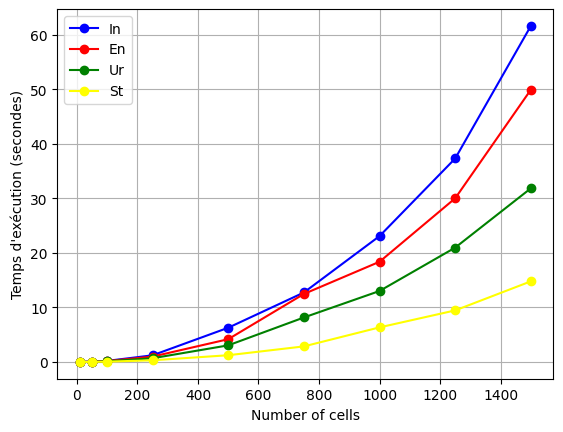

In [43]:
plt.plot(values_n, timesin, marker='o', color='blue')
plt.plot(values_n, timeseg, marker='o', color='red')
plt.plot(values_n, timesur, marker='o', color='green')
plt.plot(values_n, timesst, marker='o', color='yellow')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.legend(["In", "En", "Ur", "St"], loc="upper left")
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The main problem with the unroll function was the calculation of previously calculated elements. The Store function circumvents this problem by storing the value of the neighbor calculation for each of the three columns, so it can be reused in the next iteration. This way, only one new column needs to be calculated as the row advances. A complete recalculation of three columns is only performed at the start of a new row. This implementation makes the execution time even faster than the methods used previously.
  </p>
</div>